In [3]:
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "cleaned_output/Fitbit_Ir_cleaned"

# Load glucose (biometrics)
glucose_df = pd.read_excel(f"{BASE_DIR}/Fitbit_Ir_biometrics_cleaned.xlsx")

# Parse time
glucose_df["time"] = pd.to_datetime(glucose_df["time"], errors="coerce")

# Remove reminders / invalid values
glucose_df = glucose_df[glucose_df["value"] > 0]

# Extract date
glucose_df["date"] = glucose_df["time"].dt.date

# Daily glucose average
daily_glucose = (
    glucose_df
    .groupby("date")["value"]
    .mean()
    .reset_index(name="avg_glucose")
)


In [4]:
activity_df = pd.read_excel(
    f"{BASE_DIR}/Fitbit_Ir_physical_activity_googledata_cleaned.xlsx"
)

# Use timestamp (NOT time)
activity_df["timestamp"] = pd.to_datetime(activity_df["timestamp"], errors="coerce")
activity_df["date"] = activity_df["timestamp"].dt.date


In [5]:
daily_activity = (
    activity_df
    .groupby("date")["total_minutes"]
    .sum()
    .reset_index(name="active_minutes")
)


In [6]:
merged = pd.merge(
    daily_glucose,
    daily_activity,
    on="date",
    how="inner"
)

merged


,date,avg_glucose,active_minutes
0,2025-07-04,131.25,23
1,2025-07-07,142.00,0
2,2025-07-15,171.50,5
3,2025-07-23,179.25,49


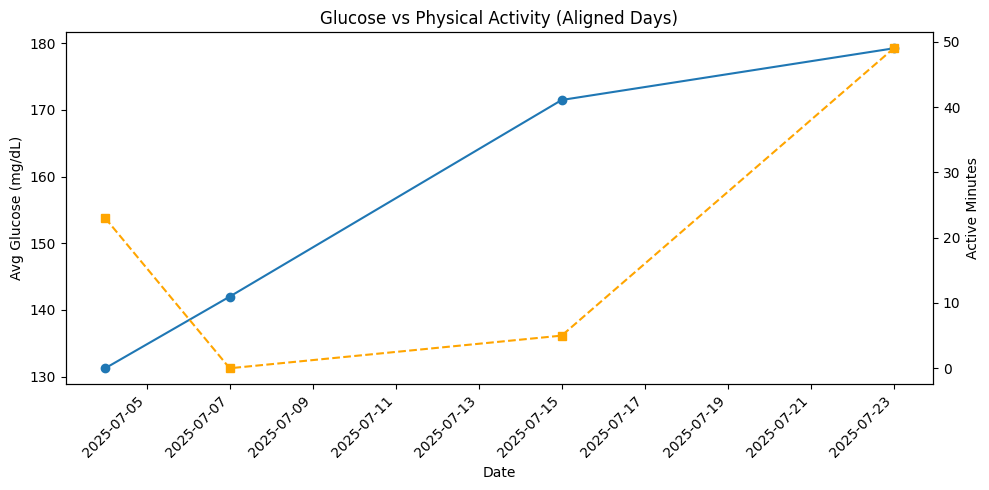

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    merged["date"],
    merged["avg_glucose"],
    marker="o",
    label="Avg Glucose (mg/dL)"
)
ax1.set_ylabel("Avg Glucose (mg/dL)")
ax1.set_xlabel("Date")

# ✅ Format dates nicely
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

ax2 = ax1.twinx()
ax2.plot(
    merged["date"],
    merged["active_minutes"],
    marker="s",
    linestyle="--",
    label="Active Minutes",
    color="orange"
)
ax2.set_ylabel("Active Minutes")

plt.title("Glucose vs Physical Activity (Aligned Days)")
plt.tight_layout()
plt.show()


Glucose vs Sleep

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "cleaned_output/Fitbit_Ir_cleaned"

# Load glucose data
glucose_df = pd.read_excel(f"{BASE_DIR}/Fitbit_Ir_biometrics_cleaned.xlsx")

# Load sleep data
sleep_df = pd.read_excel(f"{BASE_DIR}/Fitbit_Ir_sleep_score_cleaned.xlsx")


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "cleaned_output/Fitbit_Ir_cleaned"

# Load glucose data
glucose_df = pd.read_excel(f"{BASE_DIR}/Fitbit_Ir_biometrics_cleaned.xlsx")

# Load sleep data
sleep_df = pd.read_excel(f"{BASE_DIR}/Fitbit_Ir_sleep_score_cleaned.xlsx")


In [10]:
# Convert timestamp
sleep_df["timestamp"] = pd.to_datetime(sleep_df["timestamp"], errors="coerce")

# Create date column
sleep_df["date"] = sleep_df["timestamp"].dt.date

# Daily average sleep score
sleep_daily = (
    sleep_df.groupby("date")["overall_score"]
    .mean()
    .reset_index(name="sleep_score")
)

sleep_daily


,date,sleep_score
0,2025-06-27,82.0
1,2025-06-28,80.0
2,2025-06-29,64.0
3,2025-06-30,70.0
4,2025-07-01,79.0
5,2025-07-02,77.0
6,2025-07-04,76.0
7,2025-07-05,75.0
8,2025-07-06,79.0
9,2025-07-07,71.0


In [11]:
import pandas as pd

BASE_DIR = "cleaned_output/Fitbit_Ir_cleaned"

# Load glucose data
glucose_df = pd.read_excel(f"{BASE_DIR}/Fitbit_Ir_biometrics_cleaned.xlsx")

# Convert time column
glucose_df["time"] = pd.to_datetime(glucose_df["time"], errors="coerce")

# Remove invalid glucose entries (reminders etc.)
glucose_df = glucose_df[glucose_df["value"] > 0]

# Create date column
glucose_df["date"] = glucose_df["time"].dt.date

# ✅ DEFINE glucose_daily
glucose_daily = (
    glucose_df
    .groupby("date")["value"]
    .mean()
    .reset_index(name="avg_glucose")
)

glucose_daily.head()


,date,avg_glucose
0,2025-07-04,131.25
1,2025-07-07,142.00
2,2025-07-15,171.50
3,2025-07-23,179.25


In [12]:
# Load sleep data
sleep_df = pd.read_excel(f"{BASE_DIR}/Fitbit_Ir_sleep_score_cleaned.xlsx")

sleep_df["timestamp"] = pd.to_datetime(sleep_df["timestamp"], errors="coerce")
sleep_df["date"] = sleep_df["timestamp"].dt.date

sleep_daily = (
    sleep_df
    .groupby("date")["overall_score"]
    .mean()
    .reset_index(name="sleep_score")
)

merged_sleep = glucose_daily.merge(
    sleep_daily,
    on="date",
    how="inner"
)

merged_sleep


,date,avg_glucose,sleep_score
0,2025-07-04,131.25,76.0
1,2025-07-07,142.00,71.0
2,2025-07-15,171.50,79.0
3,2025-07-23,179.25,69.0


In [13]:
print(glucose_daily.columns)
print(sleep_daily.columns)


Index(['date', 'avg_glucose'], dtype='object')
Index(['date', 'sleep_score'], dtype='object')


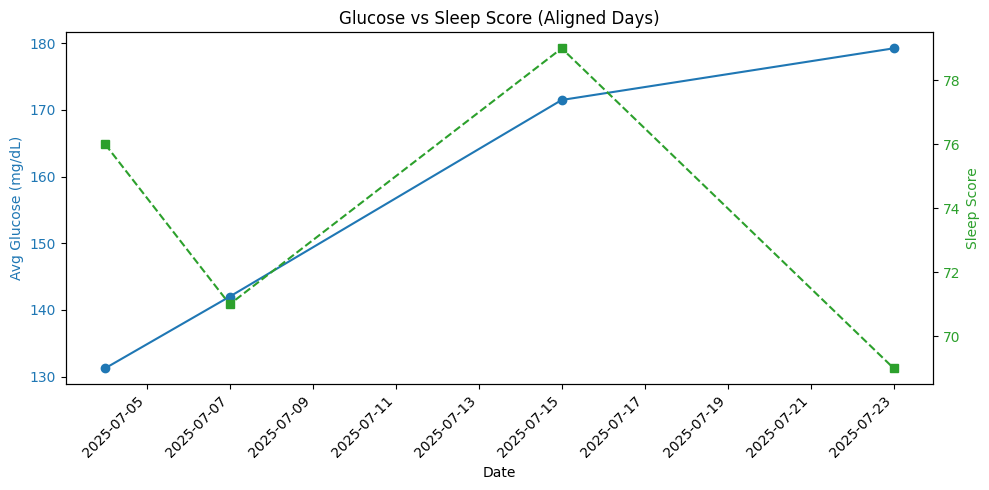

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Avg Glucose
ax1.plot(
    merged_sleep["date"],
    merged_sleep["avg_glucose"],
    marker="o",
    label="Avg Glucose (mg/dL)",
    color="tab:blue"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Avg Glucose (mg/dL)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Format date axis
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# Secondary axis for Sleep Score
ax2 = ax1.twinx()
ax2.plot(
    merged_sleep["date"],
    merged_sleep["sleep_score"],
    marker="s",
    linestyle="--",
    label="Sleep Score",
    color="tab:green"
)
ax2.set_ylabel("Sleep Score", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

# Title
plt.title("Glucose vs Sleep Score (Aligned Days)")

plt.tight_layout()
plt.show()


Glucose vs Stress

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

BASE_DIR = "cleaned_output/Fitbit_Ir_cleaned"

# Load glucose
glucose_df = pd.read_excel(f"{BASE_DIR}/Fitbit_Ir_biometrics_cleaned.xlsx")

# Load stress
stress_df = pd.read_excel(f"{BASE_DIR}/Fitbit_Ir_stress_score_cleaned.xlsx")


In [16]:
glucose_df["time"] = pd.to_datetime(glucose_df["time"], errors="coerce")

# Remove reminders / invalid entries
glucose_df = glucose_df[glucose_df["value"] > 0]

glucose_df["date"] = glucose_df["time"].dt.date

glucose_daily = (
    glucose_df
    .groupby("date")["value"]
    .mean()
    .reset_index(name="avg_glucose")
)

glucose_daily


,date,avg_glucose
0,2025-07-04,131.25
1,2025-07-07,142.00
2,2025-07-15,171.50
3,2025-07-23,179.25


In [17]:
stress_df.columns

Index(['date', 'updated_at', 'stress_score', 'sleep_points',
       'max_sleep_points', 'responsiveness_points',
       'max_responsiveness_points', 'exertion_points', 'max_exertion_points',
       'status', 'calculation_failed', 'source_file'],
      dtype='object')

In [18]:
# stress_df already has 'date' and 'stress_score'
stress_df["date"] = pd.to_datetime(stress_df["date"], errors="coerce").dt.date

stress_daily = (
    stress_df
    .groupby("date")["stress_score"]
    .mean()
    .reset_index()
)

stress_daily.head()


,date,stress_score
0,2025-06-27,0.0
1,2025-06-28,71.0
2,2025-06-29,67.0
3,2025-06-30,67.0
4,2025-07-01,71.0


In [19]:
merged_stress = glucose_daily.merge(
    stress_daily,
    on="date",
    how="inner"
)

merged_stress


,date,avg_glucose,stress_score
0,2025-07-04,131.25,72.0
1,2025-07-07,142.00,71.0
2,2025-07-15,171.50,78.0


In [20]:
merged_stress[["avg_glucose", "stress_score"]].corr()


,avg_glucose,stress_score
avg_glucose,1.000000,0.923642
stress_score,0.923642,1.000000


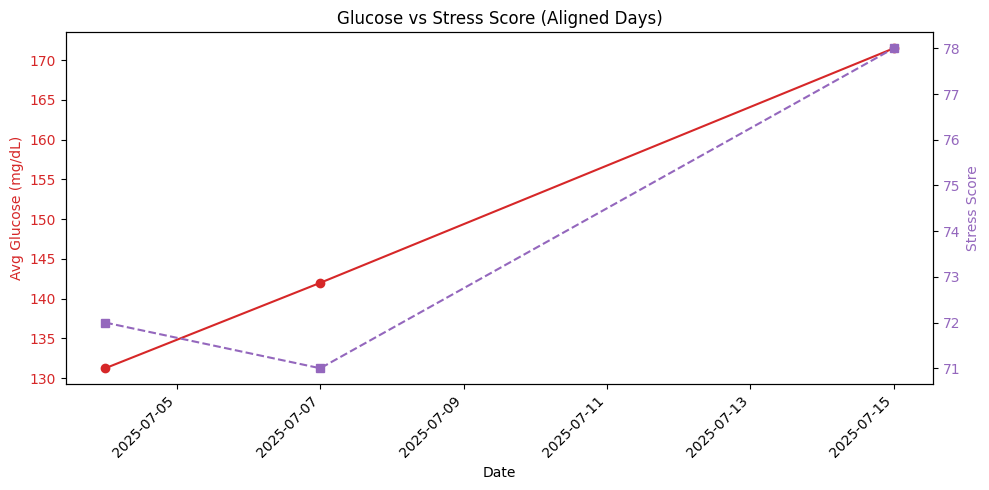

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(10, 5))

# Glucose line
ax1.plot(
    merged_stress["date"],
    merged_stress["avg_glucose"],
    marker="o",
    color="tab:red",
    label="Avg Glucose (mg/dL)"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Avg Glucose (mg/dL)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

# Format date axis
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# Stress score line
ax2 = ax1.twinx()
ax2.plot(
    merged_stress["date"],
    merged_stress["stress_score"],
    marker="s",
    linestyle="--",
    color="tab:purple",
    label="Stress Score"
)
ax2.set_ylabel("Stress Score", color="tab:purple")
ax2.tick_params(axis="y", labelcolor="tab:purple")

plt.title("Glucose vs Stress Score (Aligned Days)")
plt.tight_layout()
plt.show()


In [22]:
merged_stress[["avg_glucose", "stress_score"]].corr()


,avg_glucose,stress_score
avg_glucose,1.000000,0.923642
stress_score,0.923642,1.000000


Unified Daily Dataset (Fitbit_Ir)

In [23]:
import pandas as pd
import os


In [24]:
BASE_DIR = "cleaned_output/Fitbit_Ir_cleaned"


In [25]:
glucose_df = pd.read_excel(
    f"{BASE_DIR}/Fitbit_Ir_biometrics_cleaned.xlsx"
)

# Ensure datetime
glucose_df["time"] = pd.to_datetime(glucose_df["time"], errors="coerce")

# Remove reminders / invalid readings
glucose_df = glucose_df[glucose_df["value"] > 0]

# Daily average glucose
glucose_daily = (
    glucose_df
    .assign(date=glucose_df["time"].dt.date)
    .groupby("date")["value"]
    .mean()
    .reset_index(name="avg_glucose")
)

glucose_daily.head()


,date,avg_glucose
0,2025-07-04,131.25
1,2025-07-07,142.00
2,2025-07-15,171.50
3,2025-07-23,179.25


In [26]:
sleep_df = pd.read_excel(
    f"{BASE_DIR}/Fitbit_Ir_sleep_score_cleaned.xlsx"
)

sleep_df["timestamp"] = pd.to_datetime(
    sleep_df["timestamp"], errors="coerce"
)

sleep_daily = (
    sleep_df
    .assign(date=sleep_df["timestamp"].dt.date)
    .groupby("date")["overall_score"]
    .mean()
    .reset_index(name="sleep_score")
)

sleep_daily.head()


,date,sleep_score
0,2025-06-27,82.0
1,2025-06-28,80.0
2,2025-06-29,64.0
3,2025-06-30,70.0
4,2025-07-01,79.0


In [27]:
stress_df = pd.read_excel(
    f"{BASE_DIR}/Fitbit_Ir_stress_score_cleaned.xlsx"
)

stress_df["date"] = pd.to_datetime(
    stress_df["date"], errors="coerce"
).dt.date

stress_daily = (
    stress_df
    .groupby("date")["stress_score"]
    .mean()
    .reset_index()
)

stress_daily.head()


,date,stress_score
0,2025-06-27,0.0
1,2025-06-28,71.0
2,2025-06-29,67.0
3,2025-06-30,67.0
4,2025-07-01,71.0


In [28]:
activity_df = pd.read_excel(
    f"{BASE_DIR}/Fitbit_Ir_physical_activity_googledata_cleaned.xlsx"
)

activity_df["start_time"] = pd.to_datetime(
    activity_df["start_time"], errors="coerce"
)

activity_daily = (
    activity_df
    .assign(date=activity_df["start_time"].dt.date)
    .groupby("date")["total_minutes"]
    .sum()
    .reset_index(name="active_minutes")
)

activity_daily.head()


,date,active_minutes


In [29]:
daily_df = (
    glucose_daily
    .merge(sleep_daily, on="date", how="left")
    .merge(stress_daily, on="date", how="left")
    .merge(activity_daily, on="date", how="left")
)

daily_df


,date,avg_glucose,sleep_score,stress_score,active_minutes
0,2025-07-04,131.25,76.0,72.0,NaN
1,2025-07-07,142.00,71.0,71.0,NaN
2,2025-07-15,171.50,79.0,78.0,NaN
3,2025-07-23,179.25,69.0,NaN,NaN


In [30]:
daily_df.info()
daily_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4 non-null      object 
 1   avg_glucose     4 non-null      float64
 2   sleep_score     4 non-null      float64
 3   stress_score    3 non-null      float64
 4   active_minutes  0 non-null      float64
dtypes: float64(4), object(1)
memory usage: 292.0+ bytes


,avg_glucose,sleep_score,stress_score,active_minutes
count,4.000000,4.000000,3.000000,0.0
mean,156.000000,73.750000,73.666667,NaN
std,23.017204,4.573474,3.785939,NaN
min,131.250000,69.000000,71.000000,NaN
25%,139.312500,70.500000,71.500000,NaN
50%,156.750000,73.500000,72.000000,NaN
75%,173.437500,76.750000,75.000000,NaN
max,179.250000,79.000000,78.000000,NaN


In [31]:
daily_df["date"] = pd.to_datetime(daily_df["date"])
analysis_df = daily_df.drop(columns=["active_minutes"])
analysis_df


,date,avg_glucose,sleep_score,stress_score
0,2025-07-04,131.25,76.0,72.0
1,2025-07-07,142.00,71.0,71.0
2,2025-07-15,171.50,79.0,78.0
3,2025-07-23,179.25,69.0,NaN


In [32]:
analysis_df.drop(columns=["date"]).corr()


,avg_glucose,sleep_score,stress_score
avg_glucose,1.000000,-0.146451,0.923642
sleep_score,-0.146451,1.000000,0.860528
stress_score,0.923642,0.860528,1.000000


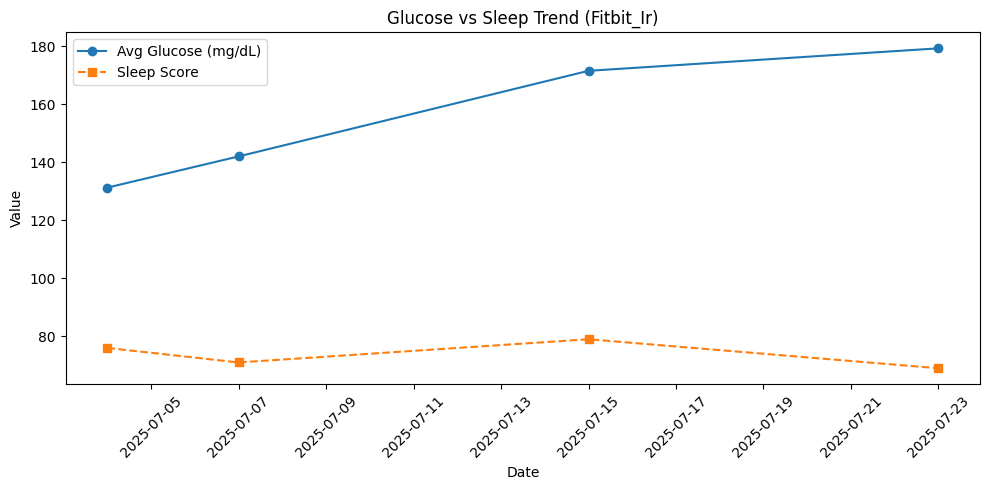

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    analysis_df["date"],
    analysis_df["avg_glucose"],
    marker="o",
    label="Avg Glucose (mg/dL)"
)
plt.plot(
    analysis_df["date"],
    analysis_df["sleep_score"],
    marker="s",
    linestyle="--",
    label="Sleep Score"
)

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Glucose vs Sleep Trend (Fitbit_Ir)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


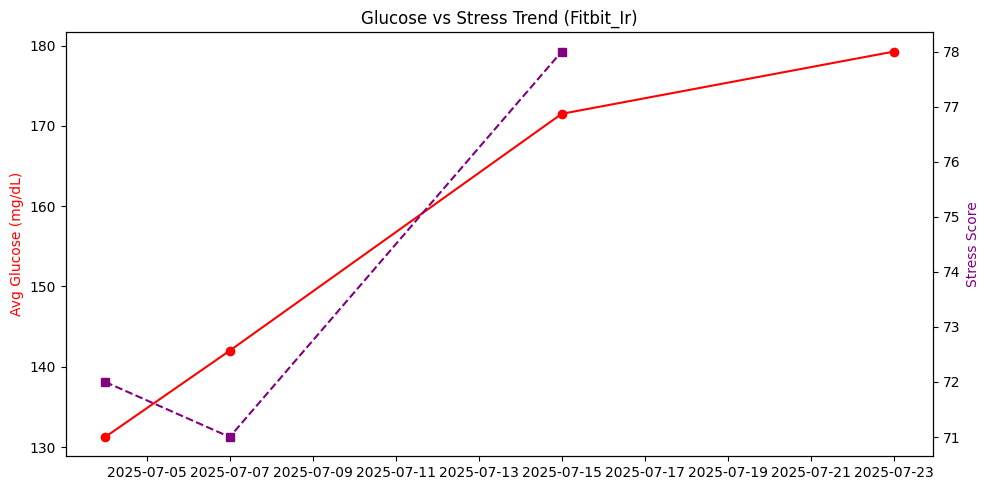

In [34]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    analysis_df["date"],
    analysis_df["avg_glucose"],
    color="red",
    marker="o",
    label="Avg Glucose"
)
ax1.set_ylabel("Avg Glucose (mg/dL)", color="red")

ax2 = ax1.twinx()
ax2.plot(
    analysis_df["date"],
    analysis_df["stress_score"],
    color="purple",
    marker="s",
    linestyle="--",
    label="Stress Score"
)
ax2.set_ylabel("Stress Score", color="purple")

plt.title("Glucose vs Stress Trend (Fitbit_Ir)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Advance Analysis

In [35]:
daily_df.isna().sum()


date              0
avg_glucose       0
sleep_score       0
stress_score      1
active_minutes    4
dtype: int64

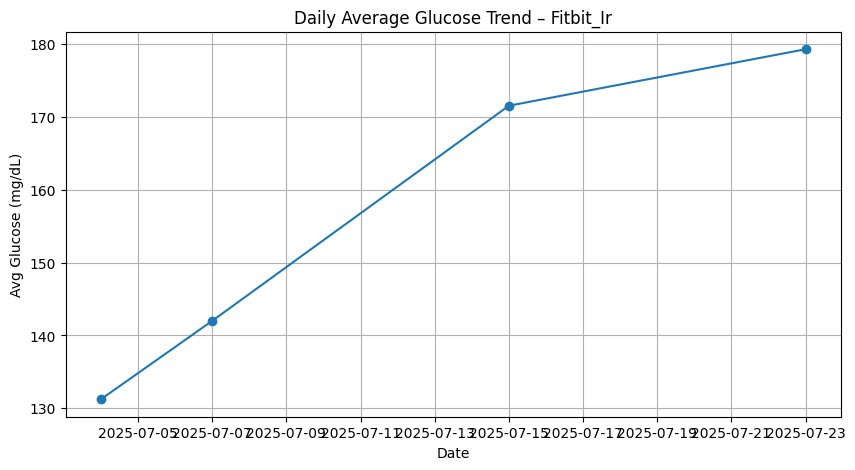

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(daily_df["date"], daily_df["avg_glucose"], marker="o")
plt.title("Daily Average Glucose Trend – Fitbit_Ir")
plt.xlabel("Date")
plt.ylabel("Avg Glucose (mg/dL)")
plt.grid(True)
plt.show()


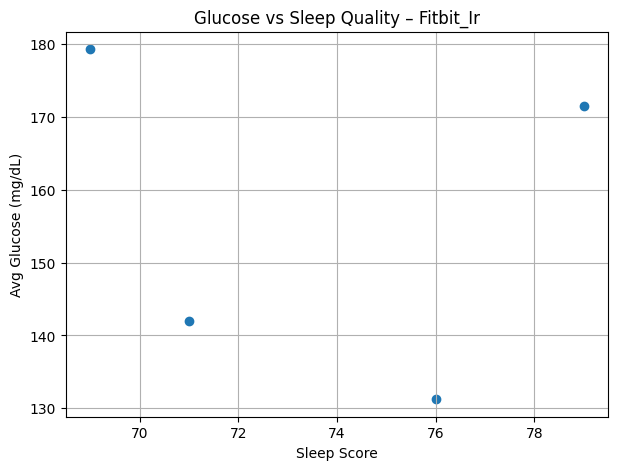

In [37]:
plt.figure(figsize=(7,5))
plt.scatter(daily_df["sleep_score"], daily_df["avg_glucose"])
plt.xlabel("Sleep Score")
plt.ylabel("Avg Glucose (mg/dL)")
plt.title("Glucose vs Sleep Quality – Fitbit_Ir")
plt.grid(True)
plt.show()


In [38]:
daily_df[["avg_glucose", "sleep_score"]].corr()


,avg_glucose,sleep_score
avg_glucose,1.000000,-0.146451
sleep_score,-0.146451,1.000000


In [39]:
daily_df["active_minutes"].isna().all()


np.True_

In [43]:
# Ensure datetime
glucose_df["time"] = pd.to_datetime(glucose_df["time"], errors="coerce")

# Remove reminders / invalid entries
glucose_df = glucose_df[glucose_df["value"] > 0]

# Create date
glucose_df["date"] = glucose_df["time"].dt.date

# Daily aggregation
daily_df = (
    glucose_df
    .groupby("date")["value"]
    .agg(
        avg_glucose="mean",
        min_glucose="min",
        max_glucose="max",
        readings="count"
    )
    .reset_index()
)

daily_df


,date,avg_glucose,min_glucose,max_glucose,readings
0,2025-07-04,131.25,103,164,4
1,2025-07-07,142.00,104,205,3
2,2025-07-15,171.50,138,202,4
3,2025-07-23,179.25,144,210,4


In [44]:
glucose_by_tag = (
    glucose_df
    .groupby("tags")["value"]
    .describe()
)

glucose_by_tag


,count,mean,std,min,25%,50%,75%,max
tags,,,,,,,,
after meal,8.0,157.000000,43.821065,103.0,129.50,147.0,202.75,210.0
before bed,3.0,184.333333,17.953644,164.0,177.50,191.0,194.50,198.0
fasting,4.0,136.250000,27.968733,108.0,114.75,136.0,157.50,165.0


In [45]:
timing_daily = (
    glucose_df
    .groupby(["date", "tags"])["value"]
    .mean()
    .reset_index()
)


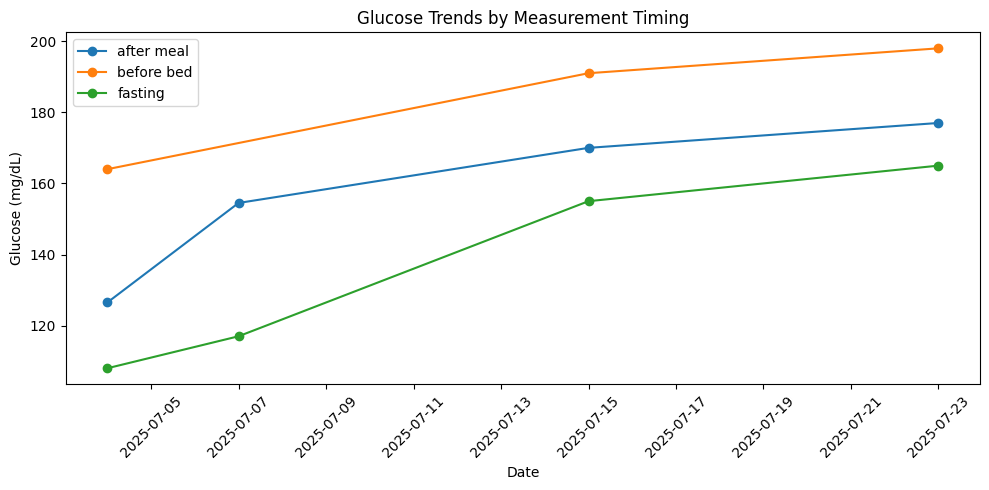

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for tag in timing_daily["tags"].unique():
    subset = timing_daily[timing_daily["tags"] == tag]
    plt.plot(subset["date"], subset["value"], marker="o", label=tag)

plt.xlabel("Date")
plt.ylabel("Glucose (mg/dL)")
plt.title("Glucose Trends by Measurement Timing")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [47]:
daily_df["glucose_range"] = daily_df["max_glucose"] - daily_df["min_glucose"]

daily_df[["date", "avg_glucose", "glucose_range"]]


,date,avg_glucose,glucose_range
0,2025-07-04,131.25,61
1,2025-07-07,142.00,101
2,2025-07-15,171.50,64
3,2025-07-23,179.25,66


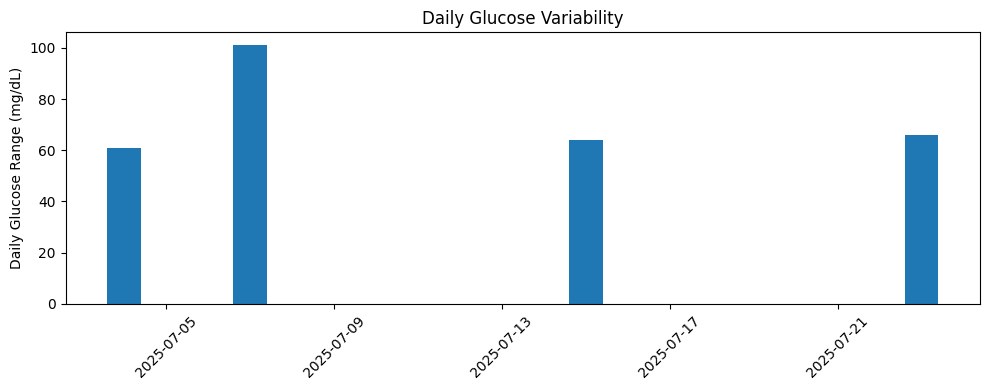

In [48]:
plt.figure(figsize=(10,4))
plt.bar(daily_df["date"], daily_df["glucose_range"])
plt.xticks(rotation=45)
plt.ylabel("Daily Glucose Range (mg/dL)")
plt.title("Daily Glucose Variability")
plt.tight_layout()
plt.show()


In [50]:
print(daily_df.columns)
print(sleep_df.columns)


Index(['date', 'avg_glucose', 'min_glucose', 'max_glucose', 'readings',
       'glucose_range'],
      dtype='object')
Index(['sleep_log_entry_id', 'timestamp', 'overall_score', 'composition_score',
       'revitalization_score', 'duration_score', 'deep_sleep_in_minutes',
       'resting_heart_rate', 'restlessness', 'source_file'],
      dtype='object')


In [51]:
sleep_df["timestamp"] = pd.to_datetime(sleep_df["timestamp"], errors="coerce")
sleep_df["date"] = sleep_df["timestamp"].dt.date


In [52]:
sleep_daily = (
    sleep_df
    .groupby("date")["overall_score"]
    .mean()
    .reset_index()
    .rename(columns={"overall_score": "sleep_score"})
)


In [53]:
sleep_daily.head()


,date,sleep_score
0,2025-06-27,82.0
1,2025-06-28,80.0
2,2025-06-29,64.0
3,2025-06-30,70.0
4,2025-07-01,79.0


In [54]:
merged_sleep = pd.merge(
    daily_df,
    sleep_daily,
    on="date",
    how="inner"
)


In [55]:
merged_sleep[["avg_glucose", "sleep_score"]].corr()


,avg_glucose,sleep_score
avg_glucose,1.000000,-0.146451
sleep_score,-0.146451,1.000000


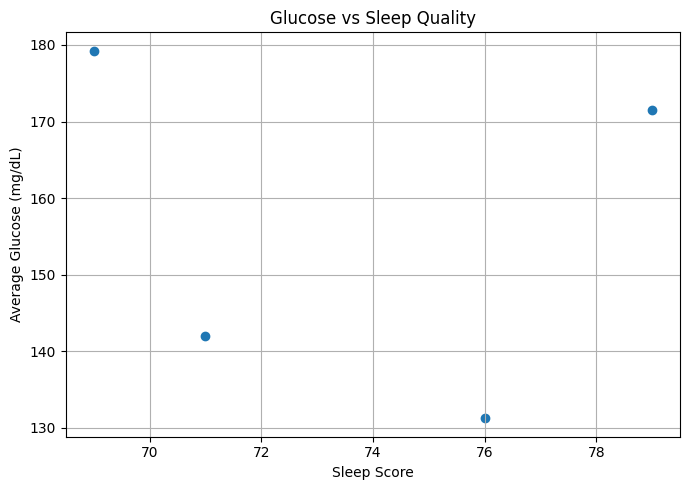

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(
    merged_sleep["sleep_score"],
    merged_sleep["avg_glucose"]
)
plt.xlabel("Sleep Score")
plt.ylabel("Average Glucose (mg/dL)")
plt.title("Glucose vs Sleep Quality")
plt.grid(True)
plt.tight_layout()
plt.show()
